### interpolacija

In [120]:
import numpy as np
import pandas as pd

def interpolate_flight(df, time_col="Time", step=0.05):
    # Original time in seconds
    orig_time = df[time_col].astype(float).to_numpy()
    start, end = orig_time.min(), orig_time.max()
    
    # Create uniform grid for this flight
    new_time = np.arange(start, end, step)
    
    # Interpolate all numeric columns
    interp_data = {"Time": new_time}
    for col in df.columns:
        if col != time_col and np.issubdtype(df[col].dtype, np.number):
            interp_data[col] = np.interp(new_time, orig_time, df[col])
    
    return pd.DataFrame(interp_data)


In [121]:
import os

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned2'
new_folder = os.path.join(folder_path, "normalized2")

# Loop through all CSV files
for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        # Read the file (semicolon-separated)
        df = pd.read_csv(file_path)
        df = df.iloc[1:]

        # Example usage for one flight
        interp_df = interpolate_flight(df, time_col="Time", step=0.05)
        print(interp_df.head())
        cleaned_filename = os.path.splitext(filename)[0] + "_normalized.csv"
        cleaned_path = os.path.join(new_folder, cleaned_filename)
        interp_df.to_csv(cleaned_path, index=False)

    Time  Position  Height above ground [m]     X [m]     Y [m]     Z [m]  \
0  4.161  0.000000                 2.930000  0.030000  0.000000 -0.010000   
1  4.211  0.352113                 2.912394  0.491268  0.003521 -0.080423   
2  4.261  0.704225                 2.894789  0.952535  0.007042 -0.150845   
3  4.311  2.191304                 2.887652  2.578957  0.000000 -0.364870   
4  4.361  2.626087                 2.905043  3.031130  0.000000 -0.421391   

   Opening Angle [°]  Stalling Angle Left [°]  Stalling Angle Right [°]  \
0           0.000000               -11.500000                -11.500000   
1           1.021127               -10.449296                -10.763380   
2           2.042254                -9.398592                -10.026761   
3           5.435652                -3.935043                 -6.317165   
4           6.653043                -2.282870                 -5.328904   

   Roll Angle Left [°]  ...  W11_Speed  W11_Tangent  W11_Turbulence  \
0             0

In [4]:
print(f"Processing file: {filename}")
print(df.columns)

Processing file: 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned.csv
Index(['Position,Height above ground [m],Time,X [m],Y [m],Z [m],Opening Angle [°],Stalling Angle Left [°],Stalling Angle Right [°],Roll Angle Left [°],Roll Angle Right [°],Yaw Angle Left [°],Yaw Angle Right [°],Speed hor. [km/h],Speed vert. [km/h],Speed resulting [km/h],W1_Speed,W1_Tangent,W1_Turbulence,W1_CleanTan,W1_Cross,W2_Speed,W2_Tangent,W2_Turbulence,W2_CleanTan,W2_Cross,W3_Speed,W3_Tangent,W3_Turbulence,W3_CleanTan,W3_Cross,W4_Speed,W4_Tangent,W4_Turbulence,W4_CleanTan,W4_Cross,W5_Speed,W5_Tangent,W5_Turbulence,W5_CleanTan,W5_Cross,W6_Speed,W6_Tangent,W6_Turbulence,W6_CleanTan,W6_Cross,W7_Speed,W7_Tangent,W7_Turbulence,W7_CleanTan,W7_Cross,W8_Speed,W8_Tangent,W8_Turbulence,W8_CleanTan,W8_Cross,W9_Speed,W9_Tangent,W9_Turbulence,W9_CleanTan,W9_Cross,W10_Speed,W10_Tangent,W10_Turbulence,W10_CleanTan,W10_Cross,W11_Speed,W11_Tangent,W11_Turbulence,W11_CleanTan,W11_Cross,W12_Speed,W12_Tangent,W12

In [59]:
# Define zones with corresponding wind columns
zones = {
    "takeoff": ["W1", "W2", "W3"],
    "mid":     ["W4", "W5", "W6", "W7"],
    "landing": ["W8", "W9", "W10", "W11", "W12"]
}

wind_features = ["Tangent", "Cross", "Turbulence"]

### preprocessing

In [122]:


def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    vx = np.gradient(x, dt)   #gradient za hitrost
    vy = np.gradient(y, dt)
    vz = np.gradient(z, dt)
    

    states = np.stack([x, y, z, vx, vy, vz], axis=1)   #zgradimo state vector X
    

    roll = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    speed = np.sqrt(vx**2 + vy**2 + vz**2)
    
    observations = np.stack([x, y, z, roll, yaw, speed], axis=1)   #zgradimo observation vector Y

    zone_feature_avgs = []
    

    for feature in wind_features:
        for zone, sensors in zones.items():
            cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
            avg_feature = df[cols].mean(axis=1).to_numpy()
            zone_feature_avgs.append(avg_feature)
    
    controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 9)
    
    return states, observations, controls


#### running čez vse

In [123]:
folder_path = r"C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned\normalized"
for filename in os.listdir(folder_path):
    if filename.endswith("_normalized.csv"):
        df = pd.read_csv(os.path.join(folder_path, filename))
        X, Y, U = preprocess_flight_normalized(df, step=0.05)
        print(filename, "->", X.shape, Y.shape, U.shape)


999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_normalized.csv -> (135, 6) (135, 6) (135, 9)
999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_normalized.csv -> (131, 6) (131, 6) (131, 9)
999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_normalized.csv -> (145, 6) (145, 6) (145, 9)
999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_normalized.csv -> (139, 6) (139, 6) (139, 9)
999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults_cleaned_normalized.csv -> (136, 6) (136, 6) (136, 9)
999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_normalized.csv -> (132, 6) (132, 6) (132, 9)
999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_normalized.csv -> (156, 6) (156, 6) (156, 9)
999_999_Jumper_Anon_ANO_1_20240409-102836_C_OfficialResults_cleaned_normalized.csv -> (134, 6) (134, 6) (134, 9)
999_999_Jumper_Anon_ANO_1_20240409-102837_C_OfficialResults_cleaned_normalized.csv -> (124, 6) (

#### preverjanje

In [38]:
filename = "999_999_Jumper_Anon_ANO_1_20240409-103924_C_OfficialResults_cleaned_normalized.csv"
df = pd.read_csv(os.path.join(folder_path, filename))
X, Y, U = preprocess_flight_normalized(df, step=0.05)

In [142]:
import os
import pandas as pd
import numpy as np

# Paths
normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned\normalized'
combined_output = os.path.join(normalized_folder, "combined_dataset.npz")

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        # Call your preprocessing function here
        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        # Append results
        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_normalized.csv -> X:(135, 6), Y:(135, 6), U:(135, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_normalized.csv -> X:(131, 6), Y:(131, 6), U:(131, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_normalized.csv -> X:(145, 6), Y:(145, 6), U:(145, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_normalized.csv -> X:(139, 6), Y:(139, 6), U:(139, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_normalized.csv -> X:(132, 6), Y:(132, 6), U:(132, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_normalized.csv -> X:(156, 6), Y:(156, 6), U:(156, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102836_C_OfficialResults_cleaned_normalized.csv -> X:(134, 6), Y:(134, 6), U:(134, 9)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102837_C_OfficialResults_cleaned_norma

In [143]:
import numpy as np

# Prepare stacked data for system identification
X_t = np.vstack([seq[:-1] for seq in X_list])      # state at time t   
X_next = np.vstack([seq[1:] for seq in X_list])    # state at time t+1  #spustimo 0. da zamaknemo
U_t = np.vstack([u[:-1] for u in U_list])          # control at time t  - matchamo s X_t
Y_t = np.vstack([obs[:-1] for obs in Y_list])      # observation at time t

print(f"X_t: {X_t.shape}, X_next: {X_next.shape}, U_t: {U_t.shape}, Y_t: {Y_t.shape}")


X_t: (26774, 6), X_next: (26774, 6), U_t: (26774, 9), Y_t: (26774, 6)


In [144]:
# Build regression matrix
Phi = np.hstack([X_t, U_t])   # [x_t | u_t]...skupaj sestavimo v eno matriko


Theta, _, _, _ = np.linalg.lstsq(Phi, X_next, rcond=None)  #rešitev po MNK (stabilna verzija)
    #output MNK: matrika A in B, reziduali, rank (A in B), singularnosti (vse razen 1. ignoriramo)

# Extract A and B
state_dim = X_t.shape[1]
control_dim = U_t.shape[1]
A = Theta[:state_dim, :].T   #prvih state_dim vrstic, vsi stolpci
B = Theta[state_dim:, :].T   #the rest (control_dim)

print("A shape:", A.shape)
print("B shape:", B.shape)


A shape: (6, 6)
B shape: (6, 9)


In [145]:
Phi_y = np.hstack([X_t, U_t])
Theta_y, _, _, _ = np.linalg.lstsq(Phi_y, Y_t, rcond=None)

obs_dim = Y_t.shape[1]
C = Theta_y[:state_dim, :].T
D = Theta_y[state_dim:, :].T

print("C shape:", C.shape)
print("D shape:", D.shape)


C shape: (6, 6)
D shape: (6, 9)


In [178]:
def simulate_trajectory(x0, U_seq, A, B):
    """
    Simulate trajectory using learned A, B.
    x0: initial state (shape: [state_dim])
    U_seq: control inputs (shape: [T, control_dim])
    """
    X_sim = [x0]  #shrani initial state
    for u in U_seq:                     # @...matrix multiplication
        x_next = A @ X_sim[-1] + B @ u  #Zračuna naslednji korak
        X_sim.append(x_next)            #shrani
    return np.array(X_sim)

# Example: take first flight  (spreminjaš 1. [] pri obeh)
x0 = X_list[0][0]      # first sublist first element
U_seq = U_list[0]      # controls for that flight
X_sim = simulate_trajectory(x0, U_seq, A, B)

print("Simulated trajectory shape:", X_sim.shape)


Simulated trajectory shape: (136, 6)


##### shranjevanje to share

In [184]:
step = 0.05
num_steps = X_state.shape[0]
time_vector = np.arange(num_steps) * step

In [185]:
import numpy as np

# Example matrices
np.savez("ssm_data.npz", 
         A=A, 
         B=B, 
         C=C, 
         D=D, 
         X_sim=X_sim, 
         U=U_seq, 
         time=time_vector)


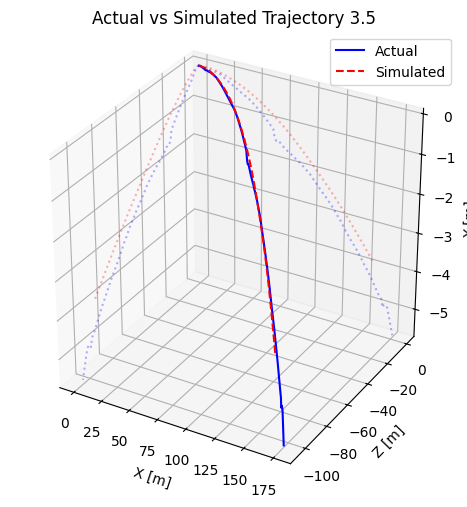

In [179]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


    #(spreminjaš 1. [] v 1. vrstici)
actual = X_list[0][:, :3]   #vzame X,Y,Z iz [x, y, z, vx, vy, vz]
sim = X_sim[:, :3]          # same iz simulacije

Xa = actual[:,0]
Ya = actual[:,1]
Za = actual[:,2]

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection='3d')

ax.plot3D(Xa, Za, Ya, label="Actual", color="blue")
ax.plot3D(sim[:,0], sim[:,2], sim[:,1], label="Simulated", color="red", linestyle="--")


# Ground projections
ax.plot(actual[:, 0], 0,actual[:, 1], color="blue", alpha=0.3, linestyle=':')
ax.plot(sim[:, 0], 0, sim[:, 1], color="red", alpha=0.3, linestyle=':')


ax.plot(0, actual[:, 2], actual[:, 1], color="blue", alpha=0.3, linestyle=':')
ax.plot(0, sim[:, 2],sim[:, 1], color="red", alpha=0.3, linestyle=':')



ax.set_title("Actual vs Simulated Trajectory 3.5")
ax.set_xlabel("X [m]")
ax.set_ylabel("Z [m]")
ax.set_zlabel("Y [m]")
ax.legend()
ax.set_box_aspect([1,1,1])

plt.legend()
plt.tight_layout()
plt.show()
